# Домашка 4 Линейная регрессия

Датасет характеристик машин: https://www.kaggle.com/datasets/vishakhdapat/price-of-used-toyota-corolla-cars
Проведем EDA датасета

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
import seaborn as sns
from scipy.stats import kstest
from scipy.stats import norm


df = pd.read_csv('ToyotaCorolla.csv', encoding='utf-8')
print("Info:")
print(df.info())
print('describe: ')
print(df.describe())


Info:
<class 'pandas.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Id                 1436 non-null   int64
 1   Model              1436 non-null   str  
 2   Price              1436 non-null   int64
 3   Age_08_04          1436 non-null   int64
 4   Mfg_Month          1436 non-null   int64
 5   Mfg_Year           1436 non-null   int64
 6   KM                 1436 non-null   int64
 7   Fuel_Type          1436 non-null   str  
 8   HP                 1436 non-null   int64
 9   Met_Color          1436 non-null   int64
 10  Color              1436 non-null   str  
 11  Automatic          1436 non-null   int64
 12  CC                 1436 non-null   int64
 13  Doors              1436 non-null   int64
 14  Cylinders          1436 non-null   int64
 15  Gears              1436 non-null   int64
 16  Quarterly_Tax      1436 non-null   int64
 17  Weight             

Проведя предобработку можно заметить:  
пустых полей нет  
два поля с текстом, которые нужно будет перевести в числа  
большой разброс в km и price
  
    
Так как в полях топлива и цвета значений немного, то применим OneHotEncoding  
А чтобы избавиться от большого разброса произведем масштабирование Price и KM с помощью minmax так как нет выбросов значений  
И в процессе будем работать с двумя датасетами чтобы оценить влияние масштабирования

In [2]:
df_copy = df.copy()
df = pd.get_dummies(df_copy, columns=['Fuel_Type', 'Color'], drop_first=True)

df_final = pd.get_dummies(df_copy, columns=['Fuel_Type', 'Color'], drop_first=True)
df_final.drop('Model', axis=1, inplace=True)
scaler = StandardScaler()

X_raw = df_final.drop('Price', axis=1)
y = df_final['Price']

X_scaled = pd.DataFrame(
    scaler.fit_transform(X_raw), 
    columns=X_raw.columns, 
    index=X_raw.index
)

df_scaled = X_scaled.copy()
df_scaled['Price'] = y

Матрица без масштабирования


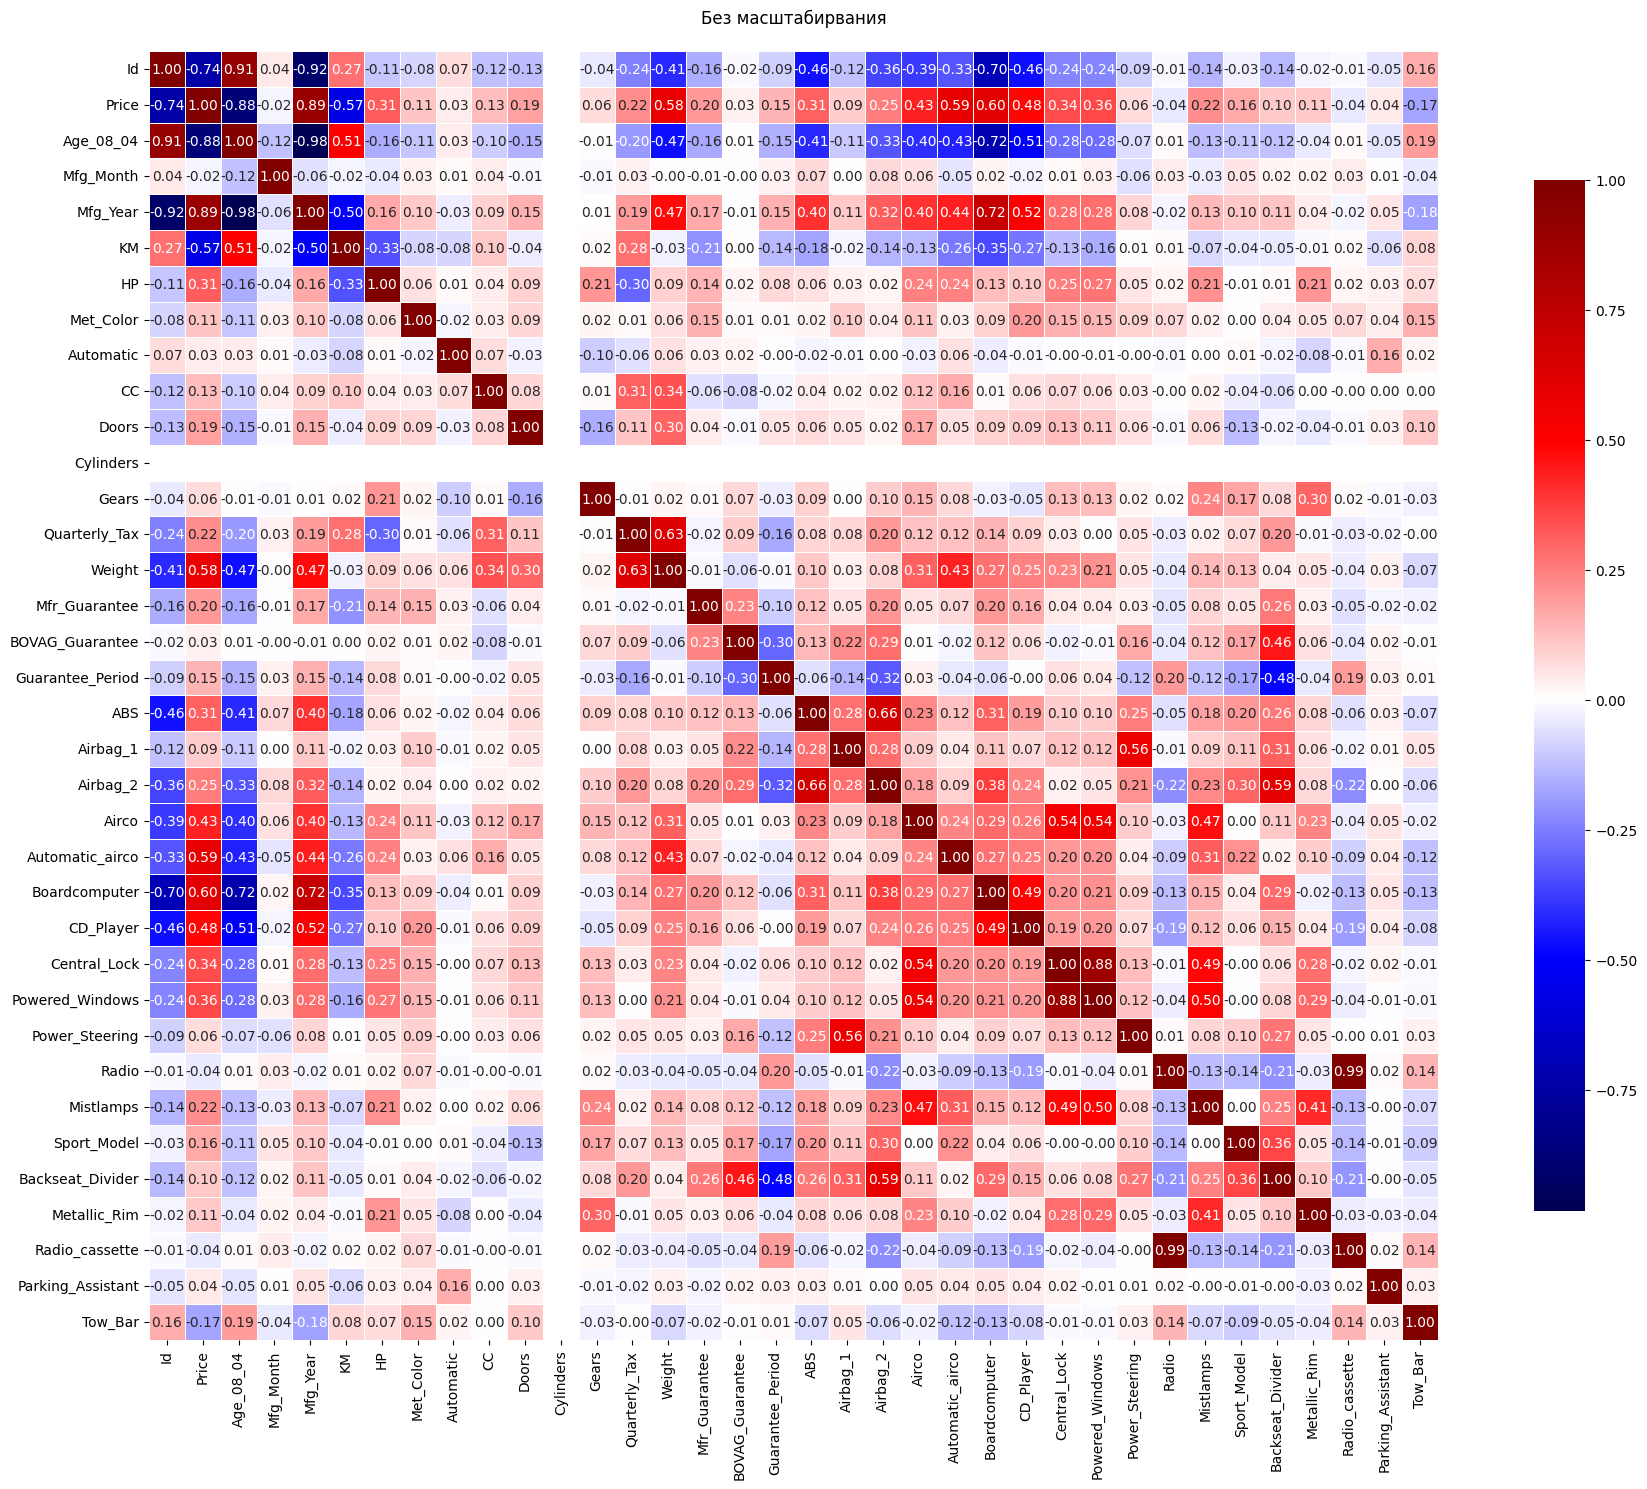

С ним


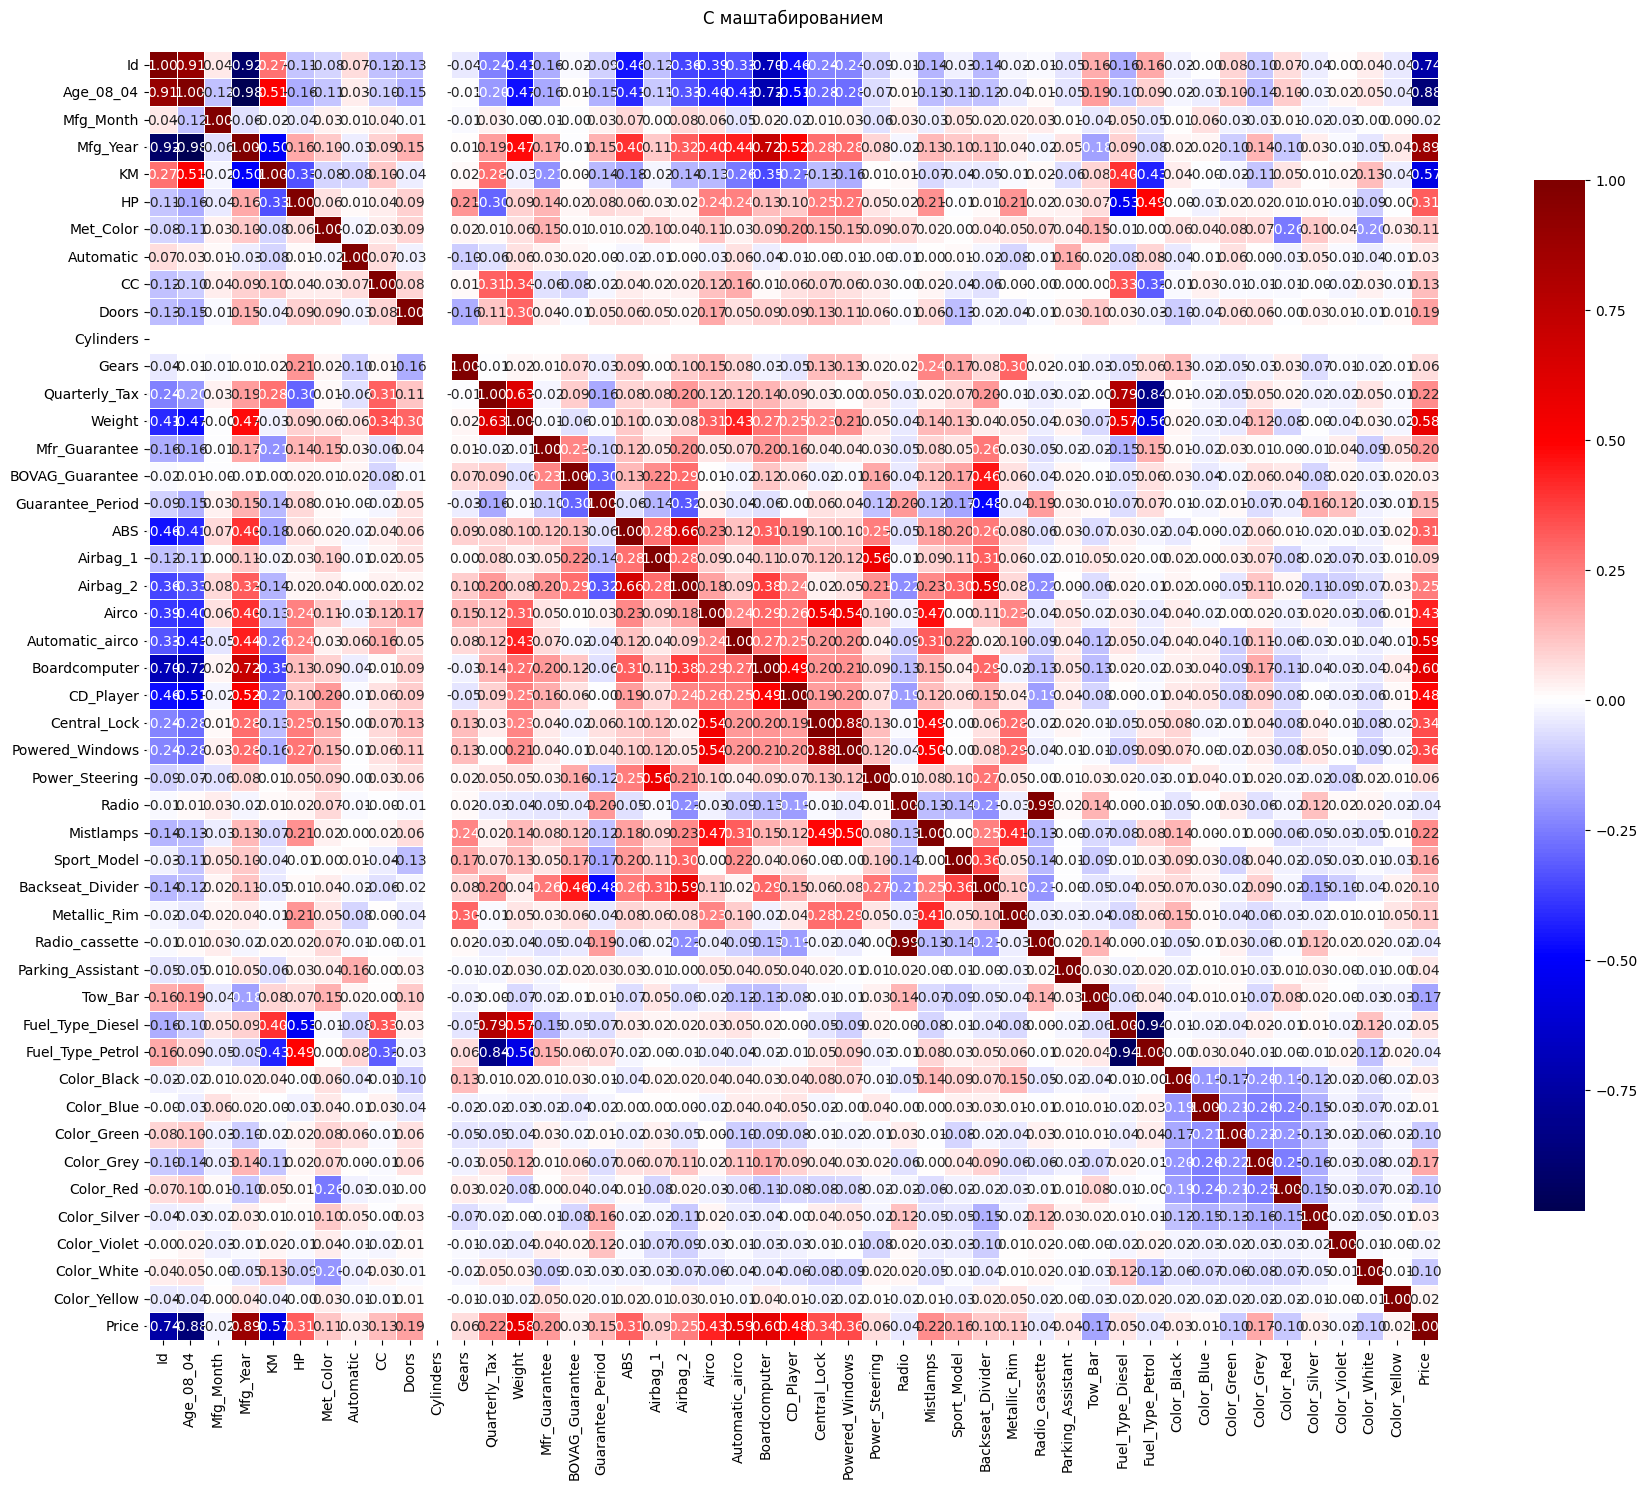

In [3]:


def MakeCorrMatr(data, title, flag, figsize=(20,15)):
    if isinstance(data, np.ndarray):
        data = pd.DataFrame(data)
        
    if flag:
        corr_matr = data.corr()
    else:
        
        numeric_cols = data.select_dtypes(include=[np.number]).columns
        corr_matr = data[numeric_cols].corr()
    if flag:
        corr_matr = data.corr()
    else:
        numeric_cols = data.select_dtypes(include=[np.number]).columns
        corr_matr = data[numeric_cols].corr()
    plt.figure(figsize=figsize)

    sns.heatmap(
        corr_matr,
        annot=True,
        fmt='.2f',
        cmap='seismic',
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={'shrink': 0.8}
    )

    plt.title(title, fontsize=12, pad=20)
    plt.tight_layout()
    plt.show()

    return corr_matr

print("Матрица без масштабирования")
corr = MakeCorrMatr(df, "Без масштабирвания", False)

print("С ним")
corr_sc = MakeCorrMatr(df_scaled, "С маштабированием", False)

In [4]:
print("Сравнение корреляций с Price (до и после масштабирования):")


price_corr_before = corr['Price'].sort_values(ascending=False)
price_corr_after = corr_sc['Price'].sort_values(ascending=False)

comparison = pd.DataFrame({
    'Корреляция ДО масштабирования': price_corr_before,
    'Корреляция ПОСЛЕ масштабирования': price_corr_after[price_corr_before.index]
})

print("Топ-10 признаков, коррелирующих с Price:")
print(comparison.head(10))




Сравнение корреляций с Price (до и после масштабирования):
Топ-10 признаков, коррелирующих с Price:
                 Корреляция ДО масштабирования  \
Price                                 1.000000   
Mfg_Year                              0.885159   
Boardcomputer                         0.601292   
Automatic_airco                       0.588262   
Weight                                0.581198   
CD_Player                             0.481374   
Airco                                 0.429259   
Powered_Windows                       0.356518   
Central_Lock                          0.343458   
HP                                    0.314990   

                 Корреляция ПОСЛЕ масштабирования  
Price                                    1.000000  
Mfg_Year                                 0.885159  
Boardcomputer                            0.601292  
Automatic_airco                          0.588262  
Weight                                   0.581198  
CD_Player                            

Оставим только те признаки, что сильно коррелируют с ценой: Mfg_Year, Boardcomputer, Automatic_airco, Weight, CD_Player, Airco, Powered_Windows, Central_Lock, HP

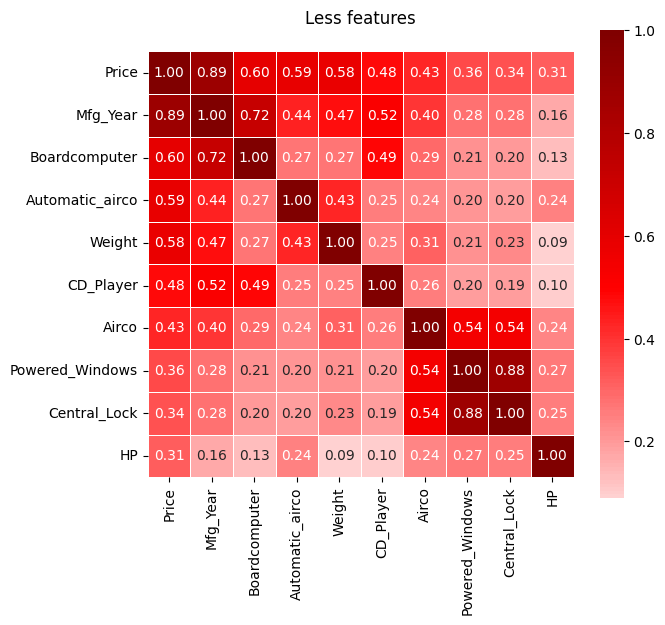

,Price,Mfg_Year,Boardcomputer,Automatic_airco,Weight,CD_Player,Airco,Powered_Windows,Central_Lock,HP
Price,1.000000,0.885159,0.601292,0.588262,0.581198,0.481374,0.429259,0.356518,0.343458,0.314990
Mfg_Year,0.885159,1.000000,0.720567,0.437718,0.473478,0.517008,0.395674,0.280996,0.279490,0.164697
Boardcomputer,0.601292,0.720567,1.000000,0.272415,0.274324,0.489725,0.293244,0.213327,0.203126,0.129715
Automatic_airco,0.588262,0.437718,0.272415,1.000000,0.430479,0.250396,0.240444,0.203687,0.195790,0.244957
Weight,0.581198,0.473478,0.274324,0.430479,1.000000,0.247056,0.310062,0.213356,0.234644,0.089614
CD_Player,0.481374,0.517008,0.489725,0.250396,0.247056,1.000000,0.257387,0.195386,0.194076,0.102300
Airco,0.429259,0.395674,0.293244,0.240444,0.310062,0.257387,1.000000,0.543982,0.540588,0.241134
Powered_Windows,0.356518,0.280996,0.213327,0.203687,0.213356,0.195386,0.543982,1.000000,0.875552,0.265593
Central_Lock,0.343458,0.279490,0.203126,0.195790,0.234644,0.194076,0.540588,0.875552,1.000000,0.250122
HP,0.314990,0.164697,0.129715,0.244957,0.089614,0.102300,0.241134,0.265593,0.250122,1.000000


In [5]:

df_main = df_scaled[["Price","Mfg_Year", "Boardcomputer", "Automatic_airco", "Weight", "CD_Player", "Airco", "Powered_Windows", "Central_Lock", "HP"]].copy()

MakeCorrMatr(df_main, "Less features", True, (7, 7))

Разделим на test train два сета: один только с сильнокоррелирующими признаками, другой - со всеми

In [ ]:
# x1 - scaled , x2 - not scaled
X1 = df_final.select_dtypes(include=np.number).drop('Price', axis=1).values
y1 = df_final['Price'].values

X_train2, X_test2, y_train2, y_test2 = train_test_split(X1, y1, test_size= 0.20, random_state=42)
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size= 0.20, random_state=42)

scaller = StandardScaler()
scaller.fit(X_train1)
X_train1 = scaller.transform(X_train1)
X_test1 = scaller.transform(X_test1)







In [7]:
linear_steps1 = [
    ('poly', PolynomialFeatures(degree = 2, include_bias = False)),
    ('model', LinearRegression())
]

regressor_linear1 = Pipeline(linear_steps1)
regressor_linear1.fit(X_train1, y_train1)

y_pred_linear1_train = regressor_linear1.predict(X_train1)
y_pred_linear1_test = regressor_linear1.predict(X_test1)

r2_score_linear1_train = r2_score(y_train1, y_pred_linear1_train)
r2_score_linear1_test = r2_score(y_test1, y_pred_linear1_test)
rmse_lin1 = np.sqrt(mean_squared_error(y_test1, y_pred_linear1_test))
mape_lin1 = mean_absolute_percentage_error(y_test1, y_pred_linear1_test)

cv_linear1 = cross_val_score(
    estimator=regressor_linear1,
    X=X_train1,
    y=y_train1,
    cv=10,
    scoring='r2')

print("LinReg dataset1: ")
print("CV mean R2: ", cv_linear1.mean())
print("R2 score train: ", r2_score_linear1_train)
print("R2 score test: ", r2_score_linear1_test)
print("RMSE: ", rmse_lin1)
print("MAPE: ", mape_lin1)

#----------------------------model 2----------------------------

linear_steps2 = [
    ('poly', PolynomialFeatures(degree = 2, include_bias = False)),
    ('model', LinearRegression())
]

regressor_linear2 = Pipeline(linear_steps2)
regressor_linear2.fit(X_train2, y_train2)

y_pred_linear2_train = regressor_linear2.predict(X_train2)
y_pred_linear2_test = regressor_linear2.predict(X_test2)

r2_score_linear2_train = r2_score(y_train2, y_pred_linear2_train)
r2_score_linear2_test = r2_score(y_test2, y_pred_linear2_test)
rmse_lin2 = np.sqrt(mean_squared_error(y_test2, y_pred_linear2_test))
mape_lin2 = mean_absolute_percentage_error(y_test2, y_pred_linear2_test)

cv_linear2 = cross_val_score(
    estimator=regressor_linear2,
    X=X_train2,
    y=y_train2,
    cv=10,
    scoring='r2')

print("LinReg dataset2: ")
print("CV mean R2: ", cv_linear2.mean())
print("R2 score train: ", r2_score_linear2_train)
print("R2 score test: ", r2_score_linear2_test)
print("RMSE: ", rmse_lin2)
print("MAPE: ", mape_lin2)

LinReg dataset1: 
CV mean R2:  -1007.4083070372595
R2 score train:  0.9688664691900923
R2 score test:  0.6012335711265933
RMSE:  2306.654776600714
MAPE:  0.1158957849056226
LinReg dataset2: 
CV mean R2:  -684.8269241165283
R2 score train:  0.9688664691488273
R2 score test:  0.569641438579638
RMSE:  2396.2853361215457
MAPE:  0.11846949071543733


Как мы видим модель только с сильнокоррелирующими признаками справилась лучше и дальше можно посмотреть на характеристики остатков

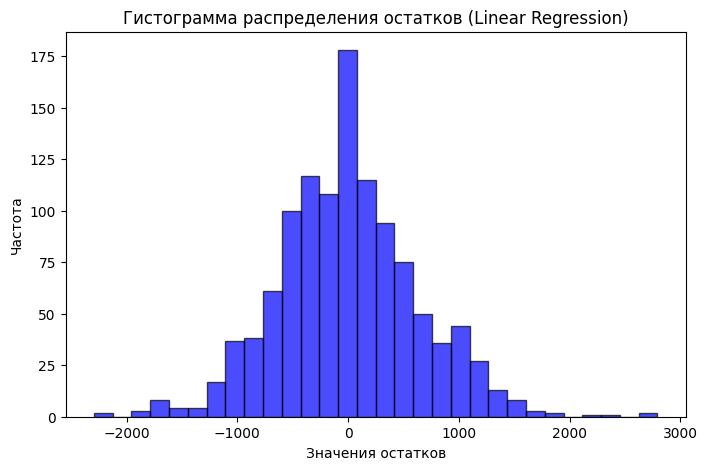

Статистика Колмогорова-Смирнова: 0.0464, P-значение: 1.3705e-02
Гипотеза о нормальном распределении остатков ОТКЛОНЯЕТСЯ (остатки не нормальны).


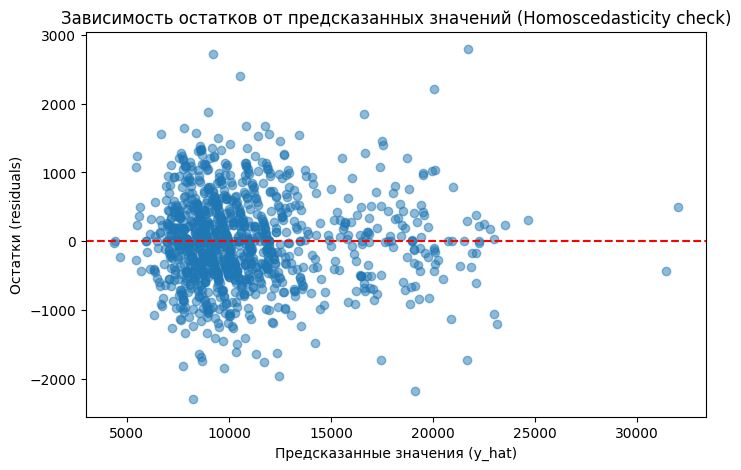

In [8]:
y_train1.ravel().shape
residuals = (y_train1.ravel() - y_pred_linear1_train.ravel())

def analyze_residuals(residuals, y_pred):
  # 1. Гистограмма остатков
  plt.figure(figsize=(8, 5))
  plt.hist(residuals, bins=30, color='blue', alpha=0.7, edgecolor='black')
  plt.title('Гистограмма распределения остатков (Linear Regression)')
  plt.xlabel('Значения остатков')
  plt.ylabel('Частота')
  plt.show()

  # 2. Проверка гипотезы о нормальности остатков (Критерий Колмогорова-Смирнова)
  residuals_mean = np.mean(residuals)
  residuals_std = np.std(residuals)
  theoretical_distribution = norm(loc=residuals_mean, scale=residuals_std)

  statistic, p_value = kstest(residuals, theoretical_distribution.cdf)
  print(f"Статистика Колмогорова-Смирнова: {statistic:.4f}, P-значение: {p_value:.4e}")

  alpha = 0.05
  if p_value < alpha:
      print("Гипотеза о нормальном распределении остатков ОТКЛОНЯЕТСЯ (остатки не нормальны).")
  else:
      print("Гипотеза о нормальном распределении остатков ПРИНИМАЕТСЯ.")

  # 3. Диаграмма рассеяния: Остатки vs Прогнозы
  plt.figure(figsize=(8,5))
  plt.scatter(y_pred.ravel(), residuals, alpha=0.5)
  plt.axhline(y=0, color='r', linestyle='--')
  plt.title('Зависимость остатков от предсказанных значений (Homoscedasticity check)')
  plt.xlabel("Предсказанные значения (y_hat)")
  plt.ylabel("Остатки (residuals)")
  plt.show()
analyze_residuals(residuals, y_pred_linear1_train)

теперь проведем регуляризацию 

In [9]:


# --- Пайплайн Ridge: скалирование + полиномы + регуляризация
ridge_steps = [
    ('scaler', StandardScaler()),                   # нормировка признаков
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', Ridge())
]

ridge_pipe = Pipeline(ridge_steps)

# --- Настройка alpha через GridSearchCV
ridge_param_grid = {
    'model__alpha': [0.1, 1.0, 10.0, 20.0, 30.0 , 50.0, 70.0 , 100.0, 120.0, 150.0, 170.0, 500.0, 1000.0, 2000.0]
}

# ищем лучший alpha по ошибке (MSE)
ridge_grid = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=ridge_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',  # чем больше, тем лучше
    n_jobs=-1
)

# обучаемся на train
ridge_grid.fit(X_train1, y_train1.ravel())

# --- Вывод лучшего alpha
best_ridge = ridge_grid.best_estimator_
best_alpha = ridge_grid.best_params_['model__alpha']
print(f"Лучший параметр alpha для Ridge: {best_alpha}")
print(f"Лучший MSE (negative) на CV: {ridge_grid.best_score_:.4f}")


Лучший параметр alpha для Ridge: 50.0
Лучший MSE (negative) на CV: -7097929.6580


In [10]:
# предсказания на train и test
y_pred_ridge_train = best_ridge.predict(X_train1)
y_pred_ridge_test = best_ridge.predict(X_test1)

# R²
r2_score_ridge_train = r2_score(y_train1.ravel(), y_pred_ridge_train)
r2_score_ridge_test  = r2_score(y_test1.ravel(),  y_pred_ridge_test)

# RMSE и MAPE
rmse_ridge = np.sqrt(mean_squared_error(y_test1.ravel(), y_pred_ridge_test))
mape_ridge = mean_absolute_percentage_error(y_test1.ravel(), y_pred_ridge_test)
mape_ridge_train = mean_absolute_percentage_error(y_train1.ravel(), y_pred_ridge_train) 

# кросс‑валидация по трейну (10‑fold, R²)
cv_ridge = cross_val_score(
    estimator=best_ridge,
    X=X_train1,
    y=y_train1.ravel(),
    cv=10,
    scoring='r2'
).mean()

print("\nRidge Regression Results (Dataset1):")
print(f"R2 Score (train): {r2_score_ridge_train:.4f}")
print(f"R2 Score (test):  {r2_score_ridge_test:.4f}")
print(f"CV Mean R2:       {cv_ridge:.4f}")
print(f"RMSE:             {rmse_ridge:.4f}")
print(f"MAPE:             {mape_ridge:.4f}")
print(f"MAPE tarin:             {mape_ridge_train:.4f}")



Ridge Regression Results (Dataset1):
R2 Score (train): 0.9625
R2 Score (test):  0.8239
CV Mean R2:       0.8563
RMSE:             1532.6928
MAPE:             0.0876
MAPE tarin:             0.0542
